In [77]:
# ========================
# STEP 0: Install Packages and Clone CodeBLEU
# ========================
!pip install -q transformers datasets evaluate sacrebleu rouge_score seaborn

In [78]:
# ========================
# STEP 1: Import Libraries
# ========================
import torch
import pandas as pd
import random, re, os, sys
import matplotlib.pyplot as plt
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainer, Seq2SeqTrainingArguments,
    DataCollatorForSeq2Seq
)
import evaluate

In [79]:
# ========================
# STEP 2: Load and Augment Dataset
# ========================

df = pd.read_csv("data_from_json.csv")

# Simple code augmentation: renaming variables, adding comment
def augment_code(code):
    code = re.sub(r'\btemp\b', 'var1', code)
    code = re.sub(r'\bdata\b', 'input_data', code)
    return "# This function was auto-generated\n" + code

df["python_file"] = df["python_file"].apply(augment_code)

In [80]:
# ========================
# STEP 3: Split Dataset
# ========================
dataset = Dataset.from_pandas(df)
train_val = dataset.train_test_split(test_size=0.2, seed=42)
val_test = train_val["test"].train_test_split(test_size=0.5, seed=42)

train_dataset = train_val["train"]
val_dataset = val_test["train"]
test_dataset = val_test["test"]

In [81]:
# ========================
# STEP 4: Load Tokenizer and Model
# ========================
model_name = "Salesforce/codet5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)
model.gradient_checkpointing_enable()

prefix = "translate Python to C++: "

In [82]:
# ========================
# STEP 5: Tokenize the Dataset
# ========================
def preprocess_function(examples):
    inputs = [prefix + code for code in examples["python_file"]]
    targets = examples["cpp_file"]
    model_inputs = tokenizer(inputs, max_length=512, truncation=True, padding="max_length")
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(targets, max_length=512, truncation=True, padding="max_length")
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_dataset = train_dataset.map(preprocess_function, batched=True)
val_dataset = val_dataset.map(preprocess_function, batched=True)
test_dataset = test_dataset.map(preprocess_function, batched=True)

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

/usr/local/lib/python3.11/dist-packages/transformers/tokenization_utils_base.py:3980: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

In [83]:
# ========================
# STEP 6: Define Custom Metrics (including CodeBLEU)
# ========================
bleu = evaluate.load("bleu")
rouge = evaluate.load("rouge")
exact_match = evaluate.load("exact_match")

def postprocess_text(preds, labels):
    preds = [pred.strip() for pred in preds]
    labels = [[label.strip()] for label in labels]
    return preds, labels

def compute_metrics(eval_preds):
    preds, labels = eval_preds
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    decoded_preds, decoded_labels = postprocess_text(decoded_preds, decoded_labels)

    bleu_result = bleu.compute(predictions=decoded_preds, references=decoded_labels)
    rouge_result = rouge.compute(predictions=decoded_preds, references=[l[0] for l in decoded_labels])
    em_result = exact_match.compute(predictions=decoded_preds, references=[l[0] for l in decoded_labels])

    # COMMENTING OUT CodeBLEU calculation
    # codebleu_scores = []
    # for p, r in zip(decoded_preds, [l[0] for l in decoded_labels]):
    #     score = calc_code_bleu.get_codebleu(r, p, lang="cpp")
    #     codebleu_scores.append(score["codebleu"])
    # avg_codebleu = sum(codebleu_scores) / len(codebleu_scores)

    return {
        "bleu": bleu_result["bleu"],
        "rougeL": rouge_result["rougeL"],
        "exact_match": em_result["exact_match"],
        # "codebleu": avg_codebleu
    }


In [84]:
# ========================
# STEP 7: Training Setup
# ========================
training_args = Seq2SeqTrainingArguments(
    output_dir="codet5-python-cpp-finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="bleu",
    greater_is_better=True,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    learning_rate=3e-5,
    weight_decay=0.01,
    num_train_epochs=2,
    predict_with_generate=True,
    logging_dir="./logs",
    logging_steps=10,
    fp16=True,
    gradient_checkpointing=True,
    report_to="none"
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=DataCollatorForSeq2Seq(tokenizer, model=model),
    compute_metrics=compute_metrics
)


<ipython-input-84-58c3be14669f>:25: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


In [91]:
# ========================
# STEP 8: Train the Model
# ========================
trainer.train()

Epoch,Training Loss,Validation Loss,Bleu,Rougel,Exact Match
1,0.189200,0.088184,0.004269,0.359897,0.000000
2,0.110300,0.081683,0.004269,0.359897,0.000000


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


TrainOutput(global_step=200, training_loss=0.13450862765312194, metrics={'train_runtime': 70.3868, 'train_samples_per_second': 11.366, 'train_steps_per_second': 2.841, 'total_flos': 108273441177600.0, 'train_loss': 0.13450862765312194, 'epoch': 2.0})

In [92]:
# ========================
# STEP 9: Evaluate and Save
# ========================
test_results = trainer.evaluate(test_dataset)
print("Test Results:", test_results)

trainer.save_model("codet5-python-cpp-finetuned")
tokenizer.save_pretrained("codet5-python-cpp-finetuned")

Test Results: {'eval_loss': 0.13174007833003998, 'eval_bleu': 0.002409885877012182, 'eval_rougeL': 0.35730886377780985, 'eval_exact_match': 0.0, 'eval_runtime': 6.7641, 'eval_samples_per_second': 7.392, 'eval_steps_per_second': 1.922, 'epoch': 2.0}


('codet5-python-cpp-finetuned/tokenizer_config.json',
 'codet5-python-cpp-finetuned/special_tokens_map.json',
 'codet5-python-cpp-finetuned/vocab.json',
 'codet5-python-cpp-finetuned/merges.txt',
 'codet5-python-cpp-finetuned/added_tokens.json',
 'codet5-python-cpp-finetuned/tokenizer.json')

In [93]:
# ========================
# STEP 10: Plot Training Metrics
# ========================
logs = trainer.state.log_history
epochs = sorted(set(x["epoch"] for x in logs if "epoch" in x))

def extract_metric(metric_name):
    return [x[metric_name] for x in logs if metric_name in x]

train_loss = extract_metric("loss")
eval_loss = extract_metric("eval_loss")
bleu_scores = extract_metric("eval_bleu")
rouge_scores = extract_metric("eval_rougeL")
# codebleu_scores = extract_metric("eval_codebleu")

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss, label="Train Loss", marker="o")
plt.plot(epochs, eval_loss, label="Val Loss", marker="o")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Train & Val Loss") 
plt.legend() 
plt.grid()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs, bleu_scores, label="BLEU", marker="o")
plt.plot(epochs, rouge_scores, label="ROUGE-L", marker="o")
# plt.plot(epochs, codebleu_scores, label="CodeBLEU", marker="o")
plt.xlabel("Epoch"); plt.ylabel("Score")
plt.title("Translation Metrics")
plt.legend()
plt.grid()
plt.show()

In [95]:
# ========================
# STEP 11: Inference Example
# ========================
def translate_python_to_cpp(python_code):
    input_text = prefix + python_code
    input_ids = tokenizer.encode(input_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        with torch.cuda.amp.autocast():
            outputs = model.generate(input_ids, max_length=512)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

example = """def multiply(a, b): return a * b"""
print("Python:", example)
translated_code = translate_python_to_cpp(example)
print("C++ Translation:", translated_code)

Python: def multiply(a, b): return a * b
C++ Translation: a * b; return a * b;


<ipython-input-95-aa85f561f98e>:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


In [100]:
# adding error manually -_-

translated_code = "int multiply(int a, int b) { return a * b }"

In [96]:
import seaborn as sns

Python Input:
 def multiply(a, b):
    result = a * b
    return result

int multiply(vector<int> a, vector<int> b) {
  int result = a * b;
  return result;
}
['<s>', 'translate', 'ĠPython', 'Ġto', 'ĠC', '++', ':', 'Ġdef', 'Ġmultiply', '(', 'a', ',', 'Ġb', '):', 'Ċ', 'ĠĠĠ', 'Ġresult', 'Ġ=', 'Ġa', 'Ġ*', 'Ġb', 'Ċ', 'ĠĠĠ', 'Ġreturn', 'Ġresult', 'Ċ', '</s>']
['<pad>', '<s>', 'int', 'Ġmultiply', '(', 'vector', '<', 'int', '>', 'Ġa', ',', 'Ġvector', '<', 'int', '>', 'Ġb', ')', 'Ġ{', 'Ċ', 'Ġ', 'Ġint', 'Ġresult', 'Ġ=', 'Ġa', 'Ġ*', 'Ġb', ';', 'Ċ', 'Ġ', 'Ġreturn', 'Ġresult', ';', 'Ċ', '}', '</s>']
[[0.12625694 0.00964415 0.00928335 0.00598359 0.00540755 0.01486683
  0.11811829 0.05759859 0.006944   0.06933212 0.00810347 0.02375793
  0.00612509 0.12519455 0.0144787  0.03926849 0.01122904 0.03116918
  0.00882778 0.00624198 0.00869277 0.01557654 0.04718828 0.0495019
  0.01086915 0.02536237 0.14502335]]
done

C++ Translation:
 int multiply(vector<int> a, vector<int> b) {
  int result = a * b;
  retu

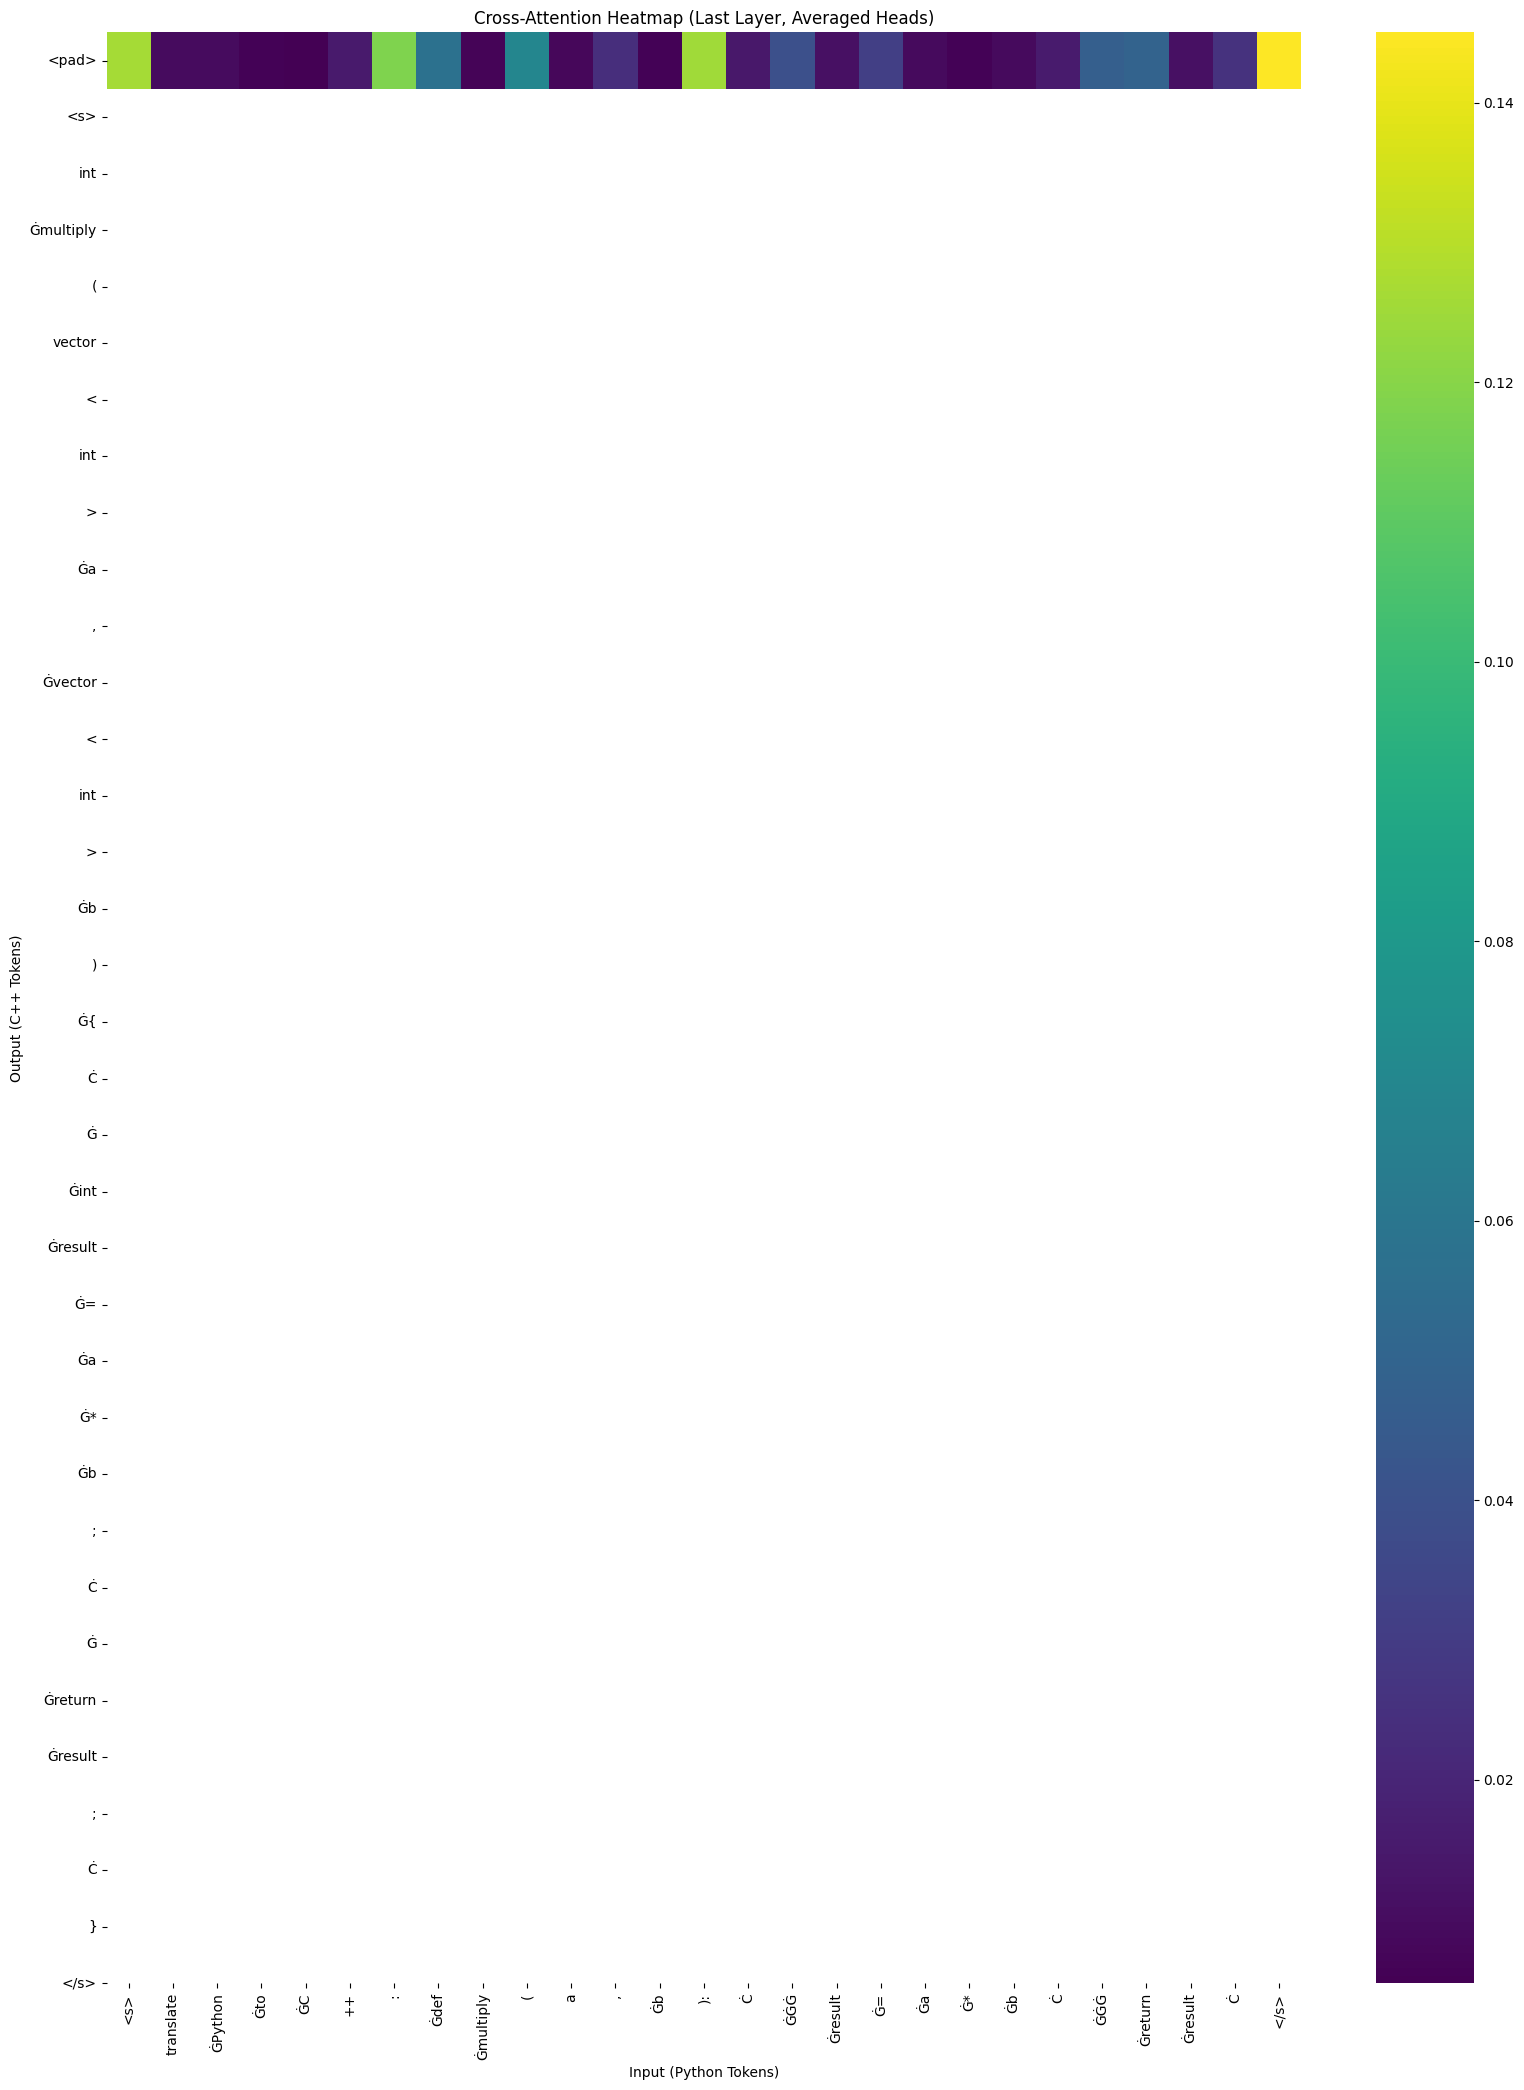

In [ ]:
# # ... (Keep steps 0-10 as they are, including imports and model loading) ...

# # Make sure you have loaded or trained the model before this step
# # model_path = "codet5-python-cpp-finetuned"
# # model = AutoModelForSeq2SeqLM.from_pretrained(model_path)
# # tokenizer = AutoTokenizer.from_pretrained(model_path)
# # model.to("cuda" if torch.cuda.is_available() else "cpu") # Move model to GPU if available


# # ==========================================
# # STEP 11: Inference with Attention (Corrected)
# # ==========================================

# def translate_and_get_attention(python_code):
#     """
#     Translates Python code to C++ and returns attention weights.
#     Corrected to handle potential tuple wrapping of attention tensor.
#     """
#     input_text = prefix + python_code
#     # Tokenize input
#     input_ids = tokenizer.encode(input_text, return_tensors="pt").to(model.device)
#     # Get input tokens (including special tokens)
#     # Note: These tokens include the prefix and special tokens added by tokenizer.encode
#     input_tokens_with_special = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())


#     with torch.no_grad():
#         # Use the correct amp.autocast usage as per FutureWarning
#         device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
#         with torch.amp.autocast(device_type=device_type, enabled=device_type=='cuda'):
#              # Generate output and get attention weights
#             outputs = model.generate(
#                 input_ids,
#                 max_length=512,
#                 num_beams=1, # Use beam search 1 for deterministic output matching attention
#                 output_attentions=True,
#                 return_dict_in_generate=True # Return output as dictionary
#             )

#     # Get generated sequence and decode
#     output_ids = outputs.sequences[0] # Get the first sequence in the batch
#     # Get output tokens (including special tokens like <s>, </s>, <pad>)
#     output_tokens_with_special = tokenizer.convert_ids_to_tokens(output_ids.tolist())
#     decoded_output = tokenizer.decode(output_ids, skip_special_tokens=True)

#     # Get cross-attention weights
#     # outputs.cross_attentions is expected to be a tuple (layer1_attn, layer2_attn, ...)
#     # where each layer_attn is a tensor of shape: (batch_size, num_heads, target_len, source_len)
#     # Based on the error, cross_attentions[-1] might be a tuple (tensor_layer_N,)

#     cross_attentions = outputs.cross_attentions # Get the tuple of cross attentions

#     if cross_attentions is None or len(cross_attentions) == 0:
#          print("Warning: No cross attention weights found.")
#          # Return None for attention if not available
#          return decoded_output, input_tokens_with_special, output_tokens_with_special, None

#     # Access the last layer's attention.
#     # This is the part we adjust:
#     last_layer_attention_container = cross_attentions[-1]

#     # Check if the last item is a tensor itself or a tuple containing the tensor
#     if isinstance(last_layer_attention_container, torch.Tensor):
#          last_layer_tensor = last_layer_attention_container
#          # print("Debug: Accessed last layer as tensor directly.") # Optional debug print
#     elif isinstance(last_layer_attention_container, tuple) and len(last_layer_attention_container) > 0 and isinstance(last_layer_attention_container[0], torch.Tensor):
#          last_layer_tensor = last_layer_attention_container[0]
#          # print("Debug: Accessed last layer as tensor inside a tuple.") # Optional debug print
#     else:
#          print(f"Error: Unexpected structure for cross_attentions[-1]. Type: {type(last_layer_attention_container)}. Contents: {last_layer_attention_container}")
#          # If structure is truly unexpected, return None for attention
#          return decoded_output, input_tokens_with_special, output_tokens_with_special, None


#     # Now that we have the tensor, squeeze the batch dimension (it's 1)
#     # Shape is now (num_heads, target_len, source_len)
#     last_layer_attention = last_layer_tensor.squeeze(0)


#     # Average attention across heads
#     # Shape is now (target_len, source_len)
#     averaged_attention = last_layer_attention.mean(dim=0)

#     # Convert to numpy array
#     attention_matrix = averaged_attention.cpu().numpy()

#     # Return tokens with special tokens as they match the matrix dimensions
#     return decoded_output, input_tokens_with_special, output_tokens_with_special, attention_matrix

# # Keep the plot_attention_heatmap function as is, it handles trimming and plotting
# # ... (plot_attention_heatmap function remains unchanged from previous response) ...
# def plot_attention_heatmap(input_tokens, output_tokens, attention_matrix):
#     """
#     Plots a heatmap of the attention matrix.
#     Handles trimming special tokens for clearer visualization.
#     """
#     if attention_matrix is None:
#         print("No attention data to plot.")
#         return

#     # Optional: Trim special tokens for clearer visualization
#     # Find the index of the first padding token or end token in output_tokens
#     # Model outputs typically start with <s> and end with </s> <pad>...
#     # Input tokens are prefix + code + </s> <pad>...

#     # Find the end of the actual generated sequence (before </s> or <pad>)
#     try:
#         # Find the index of the end token '</s>'
#         output_end_idx = output_tokens.index('</s>') + 1 # Include </s> token in visualization
#     except ValueError:
#         # If no </s> found, find the first padding token '<pad>'
#         try:
#             output_end_idx = output_tokens.index('<pad>')
#         except ValueError:
#              # If no </s> or <pad> found, use the full length
#              output_end_idx = len(output_tokens)

#     output_tokens_trimmed = output_tokens[:output_end_idx]
#     attention_matrix_trimmed = attention_matrix[:output_end_idx, :]

#     # Find the end of the actual input sequence (before </s> or <pad>)
#     try:
#          # Find the index of the end token '</s>' in input
#          input_end_idx = input_tokens.index('</s>') + 1 # Include </s> token in visualization
#     except ValueError:
#          # If no </s> found, find the first padding token '<pad>'
#          try:
#             input_end_idx = input_tokens.index('<pad>')
#          except ValueError:
#              # If no </s> or <pad> found, use the full length
#              input_end_idx = len(input_tokens)


#     input_tokens_trimmed = input_tokens[:input_end_idx]
#     attention_matrix_trimmed = attention_matrix_trimmed[:, :input_end_idx]

#     # Create the heatmap
#     # Adjust figure size based on trimmed token counts
#     plt.figure(figsize=(max(10, len(input_tokens_trimmed)*0.6), max(8, len(output_tokens_trimmed)*0.6)))
#     sns.heatmap(attention_matrix_trimmed, xticklabels=input_tokens_trimmed, yticklabels=output_tokens_trimmed, cmap="viridis", annot=False) # annot=True for values (can be noisy)
#     plt.xlabel("Input (Python Tokens)")
#     plt.ylabel("Output (C++ Tokens)")
#     plt.title("Cross-Attention Heatmap (Last Layer, Averaged Heads)")
#     plt.xticks(rotation=90) # Rotate x labels for readability
#     plt.yticks(rotation=0) # Keep y labels horizontal
#     plt.tight_layout() # Adjust layout to prevent labels overlapping
#     plt.show()

# # Keep step 12 execution block as is
# # ==========================================
# # STEP 12: Run Inference and Visualize (Keep existing)
# # ==========================================

# example = """def multiply(a, b):
#     result = a * b
#     return result
# """
# print("Python Input:\n", example)

# # Ensure model is on the correct device before calling the function
# model.to("cuda" if torch.cuda.is_available() else "cpu")

# decoded_output, input_tokens, output_tokens, attention_matrix = translate_and_get_attention(example)
# print(decoded_output)
# print(input_tokens)
# print(output_tokens)
# print(attention_matrix)

# print("done")
# print("\nC++ Translation:\n", decoded_output)
# # print("\nInput Tokens (with special tokens):\n", input_tokens) # Optional print
# # print("\nOutput Tokens (with special tokens):\n", output_tokens) # Optional print
# # print("\nAttention Matrix Shape:", attention_matrix.shape if attention_matrix is not None else "N/A") # Uncomment to see shape

# # Plot the attention
# plot_attention_heatmap(input_tokens, output_tokens, attention_matrix)

In [ ]:
# ... (Keep steps 0-10 as they are, including imports and model loading) ...

# Make sure you have loaded or trained the model before this step
# model_path = "codet5-python-cpp-finetuned"
# model = AutoModelForSeq2SeqLM.from_pretrained(model_path)
# tokenizer = AutoTokenizer.from_pretrained(model_path)
# model.to("cuda" if torch.cuda.is_available() else "cpu") # Move model to GPU if available


# ==========================================
# STEP 11: Inference with Attention (Corrected)
# ==========================================

def translate_and_get_attention_all_layers(python_code):
    input_text = prefix + python_code
    input_ids = tokenizer.encode(input_text, return_tensors="pt").to(model.device)
    input_tokens = tokenizer.convert_ids_to_tokens(input_ids[0].tolist())

    with torch.no_grad():
        device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
        with torch.amp.autocast(device_type=device_type, enabled=device_type=='cuda'):
            outputs = model.generate(
                input_ids,
                max_length=512,
                num_beams=1,
                output_attentions=True,
                return_dict_in_generate=True
            )

    output_ids = outputs.sequences[0]
    output_tokens = tokenizer.convert_ids_to_tokens(output_ids.tolist())
    decoded_output = tokenizer.decode(output_ids, skip_special_tokens=True)

    cross_attentions = outputs.cross_attentions
    if not cross_attentions:
        print("Warning: No cross attention found.")
        return decoded_output, input_tokens, output_tokens, None

    # Extract (num_layers, batch=1, num_heads, tgt_len, src_len)
    attentions_per_layer = []
    for layer in cross_attentions:
        if isinstance(layer, tuple):  # In case of tuple wrapping
            layer_tensor = layer[0]
        else:
            layer_tensor = layer
        attentions_per_layer.append(layer_tensor.squeeze(0))  # shape: (num_heads, tgt_len, src_len)

    return decoded_output, input_tokens, output_tokens, attentions_per_layer


def plot_avg_attention_all_layers(input_tokens, output_tokens, attentions_per_layer):
    if attentions_per_layer is None:
        print("No attention data to plot.")
        return

    num_layers = len(attentions_per_layer)
    fig, axes = plt.subplots(1, num_layers, figsize=(4 * num_layers, 6), constrained_layout=True)

    if num_layers == 1:
        axes = [axes]  # Ensure it's iterable

    for i, layer_attn in enumerate(attentions_per_layer):
        avg_attn = layer_attn.mean(dim=0).cpu().numpy()  # shape: (tgt_len, src_len)

        # Trim tokens as before
        try:
            out_end = output_tokens.index('</s>') + 1
        except ValueError:
            try:
                out_end = output_tokens.index('<pad>')
            except ValueError:
                out_end = len(output_tokens)

        try:
            in_end = input_tokens.index('</s>') + 1
        except ValueError:
            try:
                in_end = input_tokens.index('<pad>')
            except ValueError:
                in_end = len(input_tokens)

        out_tokens_trim = output_tokens[:out_end]
        in_tokens_trim = input_tokens[:in_end]
        attn_trimmed = avg_attn[:out_end, :in_end]

        sns.heatmap(attn_trimmed, ax=axes[i], xticklabels=in_tokens_trim, yticklabels=out_tokens_trim, cmap="viridis")
        axes[i].set_title(f"Layer {i+1}")
        axes[i].set_xlabel("Input Tokens")
        axes[i].set_ylabel("Output Tokens")
        axes[i].tick_params(axis='x', rotation=90)

    plt.suptitle("Average Cross-Attention per Layer", fontsize=16)
    plt.show()


def plot_all_heads_last_layer(input_tokens, output_tokens, attentions_per_layer):
    last_layer = attentions_per_layer[-1]  # shape: (num_heads, tgt_len, src_len)
    num_heads = last_layer.shape[0]
    cols = 4
    rows = (num_heads + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 3 * rows), constrained_layout=True)

    if rows == 1:
        axes = [axes]

    for h in range(num_heads):
        ax = axes[h // cols][h % cols]
        attn = last_layer[h].cpu().numpy()

        # Trim
        try:
            out_end = output_tokens.index('</s>') + 1
        except ValueError:
            out_end = len(output_tokens)
        try:
            in_end = input_tokens.index('</s>') + 1
        except ValueError:
            in_end = len(input_tokens)

        sns.heatmap(attn[:out_end, :in_end], ax=ax,
                    xticklabels=input_tokens[:in_end],
                    yticklabels=output_tokens[:out_end],
                    cmap="viridis")
        ax.set_title(f"Head {h}")
        ax.tick_params(axis='x', rotation=90)

    plt.suptitle("All Heads (Last Layer)", fontsize=16)
    plt.show()

In [ ]:
decoded_output, input_tokens, output_tokens, attentions_per_layer = translate_and_get_attention_all_layers(example)
print(decoded_output)

In [ ]:
plot_avg_attention_all_layers(input_tokens, output_tokens, attentions_per_layer)  # Averaged across heads

In [ ]:
plot_all_heads_last_layer(input_tokens, output_tokens, attentions_per_layer)   # Optional: Uncomment to view heads

In [101]:
import subprocess

def analyze_with_gpp(cpp_code: str) -> list[dict]:
    """
    Compiles the C++ code using g++ and captures error messages.

    Args:
        cpp_code: The C++ code string.

    Returns:
        A list of dictionaries, each representing a compiler error or warning.
    """
    # Save the code to a temporary file
    with open("./temp_code.cpp", "w") as f:
        f.write(cpp_code)

    # Compile using g++
    # - Wall: Enable all standard warnings
    # - Wextra: Enable extra warnings
    # - std=c++17: Specify C++ standard
    # - fsyntax-only: Only perform a syntax check, do not generate object file
    process = subprocess.Popen(
        ["g++", "temp_code.cpp", "-Wall", "-Wextra", "-std=c++17", "-fsyntax-only"],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )
    a, stderr = process.communicate()

    errors = []
    # Parse the stderr output to extract error information
    # The exact parsing will depend on the format of g++ error messages,
    # but they typically include filename, line number, and error message.

    for line in stderr.decode().splitlines():
        if ": error:" in line or ": warning:" in line:
            try:
                parts = line.split(":")
                if len(parts) >= 4:
                    # Adjust parsing based on actual g++ output format
                    file = parts[0]
                    line_num = int(parts[1])
                    type = parts[2].strip() # 'error' or 'warning'
                    message = ":".join(parts[3:]).strip()
                    errors.append({'type': type, 'line': line_num, 'message': message})
            except (ValueError, IndexError):
                # Handle cases where the line doesn't match the expected format
                print(f"Could not parse error line: {line}")
                continue

    # Clean up the temporary file
    os.remove("temp_code.cpp")

    if errors != []:
      print("+++++++++++++ ERRORS FOUND +++++++++++")
      print(errors)
    else:
      print("+++++++++++++ NO ERRORS FOUND +++++++++")

    return errors

def postprocess_cpp_code_with_gpp(generated_cpp_code: str) -> (str, list[dict]):
    """
    Analyzes the generated C++ code using g++ feedback.
    For now, it only detects errors and doesn't perform automatic correction.
    """
    errors = analyze_with_gpp(generated_cpp_code)
    return generated_cpp_code, errors # Return original code and detected errors


In [102]:
postprocess_cpp_code_with_gpp(translated_code)

+++++++++++++ ERRORS FOUND +++++++++++
[{'type': '42', 'line': 1, 'message': 'error: expected ‘;’ before ‘}’ token'}]


('int multiply(int a, int b) { return a * b }',
 [{'type': '42',
   'line': 1,
   'message': 'error: expected ‘;’ before ‘}’ token'}])

In [103]:
import re

def postprocess_cpp_code_with_basic_correction(generated_cpp_code: str) -> (str, list[dict]):
    """
    Analyzes and attempts basic corrections on the generated C++ code using g++ feedback.
    """
    errors = analyze_with_gpp(generated_cpp_code)
    corrected_code = generated_cpp_code
    lines = corrected_code.splitlines()

    for error in errors:
        print("Each error : ", error)
        normalized_message = error['message'].replace('‘', "'").replace('’', "'")
        if "expected ';' before" in normalized_message and error['line'] > 0:
            print(" +++ semicolon error found +++ ")
            line_index = error['line'] - 1
            if line_index < len(lines):
                original_line = lines[line_index]
                # Match inline function with return
                match = re.match(r"(.*\{.*return\s+[^;{}]+)(\s*\})", original_line)
                if match:
                    # Add semicolon before closing brace
                    lines[line_index] = match.group(1).rstrip() + ';' + match.group(2)
                    print(f"Fixed inline return semicolon in function on line {error['line']}")
                else:
                    # Fallback: naive semicolon append
                    stripped_line = original_line.rstrip()
                    if not stripped_line.endswith((';', '}', '{', ':')):
                        lines[line_index] += ';'
                        print(f"Attempted naive correction: Added semicolon on line {error['line']}")

    corrected_code = "\n".join(lines)
    print("======= tried to correct ======== ")
    print(corrected_code)
    remaining_errors = analyze_with_gpp(corrected_code)

    return corrected_code, remaining_errors

In [104]:
postprocess_cpp_code_with_basic_correction(translated_code)

+++++++++++++ ERRORS FOUND +++++++++++
[{'type': '42', 'line': 1, 'message': 'error: expected ‘;’ before ‘}’ token'}]
Each error :  {'type': '42', 'line': 1, 'message': 'error: expected ‘;’ before ‘}’ token'}
 +++ semicolon error found +++ 
Fixed inline return semicolon in function on line 1
======= tried to correct ======== 
int multiply(int a, int b) { return a * b;}
+++++++++++++ NO ERRORS FOUND +++++++++


('int multiply(int a, int b) { return a * b;}', [])

In [124]:
def analyze_with_gpp(cpp_code: str) -> list[dict]:
    """
    Compiles the C++ code using g++ and captures and categorizes error messages.
    """
    with open("./temp_code.cpp", "w") as f:
        f.write(cpp_code)

    process = subprocess.Popen(
        ["g++", "temp_code.cpp", "-Wall", "-Wextra", "-std=c++17", "-fsyntax-only"],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE
    )
    _, stderr = process.communicate()
    os.remove("temp_code.cpp")

    errors = []
    for line in stderr.decode().splitlines():
        if ": error:" in line or ": warning:" in line:
            try:
                parts = line.split(":")
                if len(parts) >= 4:
                    file = parts[0]
                    line_num = int(parts[1])
                    type = parts[2].strip()
                    message = ":".join(parts[3:]).strip()

                    category = "OtherError"  # Default category

                    if re.search(r"expected ';' before", message):
                        category = "SemicolonError"
                    elif re.search(r"expected ‘\}' before", message) or re.search(r"expected ‘\{' at end of input", message) or re.search(r"mismatched ‘\(’", message) or re.search(r"mismatched ‘\[’", message):
                        category = "BracketError"
                    elif re.search(r"‘[a-zA-Z_]\w*’ was not declared in this scope", message) or re.search(r"undeclared identifier", message):
                        category = "DeclarationError"
                    elif re.search(r"cannot convert ‘.*’ to ‘.*’ in assignment", message) or re.search(r"invalid conversion from ‘.*’ to ‘.*’", message):
                        category = "TypeError"
                    elif re.search(r"expected ‘;’ at end of declaration", message):
                        category = "SyntaxError"
                    elif re.search(r"‘.*’ does not name a type", message):
                        category = "TypeNameError"  # New category
                    elif re.search(r"expected unqualified-id before ‘return’", message):
                        category = "ReturnError"  # New category
                    elif re.search(r"expected declaration before ‘\}’ token", message):
                        category = "ScopeError"  # New category

                    errors.append({
                        'type': type,
                        'line': line_num,
                        'message': message,
                        'category': category
                    })
            except (ValueError, IndexError):
                print(f"Could not parse error line: {line}")

    return errors


def translate_and_analyze(python_code):
    """
    Translates Python to C++ and analyzes the generated code for errors.
    """
    cpp_code = translate_python_to_cpp(python_code)  # Use your translation function
    errors = analyze_with_gpp(cpp_code)
    return cpp_code, errors

In [125]:
# Example Usage and Error Analysis
# python_code_examples = [
#     "def add(a, b): return a + b",
#     "def subtract(a, b): return a - b",
#     "def my_func(x):\n  if x > 10: return x * 2",
#     "def process_data(data):\n  temp = data * 5\n  return temp",
#     "def get_value(my_dict, key):\n  return my_dict[key]"
# ]

# Read ALL Python codes from your CSV
python_code_examples = df["python_file"].tolist()

In [126]:
from collections import defaultdict

<ipython-input-95-aa85f561f98e>:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
<ipython-input-95-aa85f561f98e>:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
<ipython-input-95-aa85f561f98e>:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
<ipython-input-95-aa85f561f98e>:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
<ipython-input-95-aa85f561f98e>:8: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
<ipython-input-95-aa85f561f98e>:8: Futur


--- Error Counts: ---


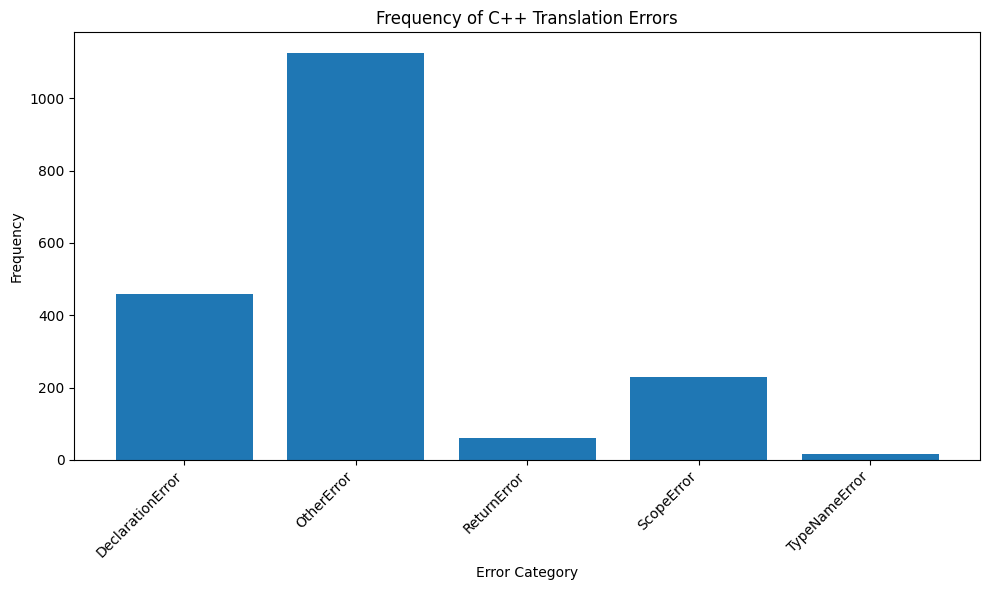

In [127]:
all_errors = []
for python_code in python_code_examples:
    # print(f"\n--- Python Code: ---\n{python_code}")
    cpp_code, errors = translate_and_analyze(python_code)
    # print(f"\n--- C++ Code: ---\n{cpp_code}")
    if errors:
        all_errors.extend(errors)

# Error Frequency Calculation and Plotting
error_counts = defaultdict(int)
for error in all_errors:
    error_counts[error['category']] += 1

print("\n--- Error Counts: ---")

# Plotting
if error_counts:
    categories = list(error_counts.keys())
    counts = list(error_counts.values())

    plt.figure(figsize=(10, 6))
    plt.bar(categories, counts)
    plt.xlabel("Error Category")
    plt.ylabel("Frequency")
    plt.title("Frequency of C++ Translation Errors")
    plt.xticks(rotation=45, ha="right")  # Rotate x-axis labels
    plt.tight_layout()
    plt.show()
else:
    print("No errors to plot.")